In [68]:
import cobra
import pickle
from gem_utilities import media

In [ ]:
model = cobra.io.read_sbml_model("../model.xml")

In [ ]:
# Load the media
# Load the media definitions
with open("../test/test_files/media/media_definitions.pkl", "rb") as f:
    media_definitions = pickle.load(f)

In [85]:
# Make the acetate medium
l1_ace = media_definitions["l1"]
l1_ace["EX_cpd00029_e0"] = 1000

In [86]:
# Set the model medium to L1 acetate
model.medium = media.clean_media(model, l1_ace)

/Users/helenscott/Documents/PhD/Segre-lab/GEM-utils/gem_utilities/media.py:31: UserWarning: Model does not have the exchange reaction EX_cpd20826_e0, so it was not set in the media.
  warnings.warn(
/Users/helenscott/Documents/PhD/Segre-lab/GEM-utils/gem_utilities/media.py:31: UserWarning: Model does not have the exchange reaction EX_cpd00240_e0, so it was not set in the media.
  warnings.warn(
/Users/helenscott/Documents/PhD/Segre-lab/GEM-utils/gem_utilities/media.py:31: UserWarning: Model does not have the exchange reaction EX_cpd11574_e0, so it was not set in the media.
  warnings.warn(
/Users/helenscott/Documents/PhD/Segre-lab/GEM-utils/gem_utilities/media.py:31: UserWarning: Model does not have the exchange reaction EX_cpd03387_e0, so it was not set in the media.
  warnings.warn(
/Users/helenscott/Documents/PhD/Segre-lab/GEM-utils/gem_utilities/media.py:31: UserWarning: Model does not have the exchange reaction EX_cpd08438_e0, so it was not set in the media.
  warnings.warn(
/User

# Check if TCA cycle reactions are blocked

In [87]:
tca_reaction_ids = [
    "rxn00256_c0",
    "rxn00974_c0",
    "rxn01388_c0",
    "rxn01387_c0",
    "rxn00199_c0",
    "rxn00441_c0",
    "rxn02376_c0",
    "rxn01872_c0",
    "rxn00285_c0",
    "rxn00288_c0",
    "rxn00799_c0",
    "rxn00248_c0"
    ]

In [89]:
# Make a dictionary to hold the results
results = {}

# Try setting each reaction as the objective
for rxn_id in tca_reaction_ids:
    
    # Set the objective to the current TCA step
    model.objective = rxn_id
    
    # Optimize
    solution = model.optimize()
    
    # Store the full solution
    results[rxn_id] = solution

In [90]:
results

{'rxn00256_c0': <Solution 910.000 at 0x1150316d0>,
 'rxn00974_c0': <Solution 910.000 at 0x115032750>,
 'rxn01388_c0': <Solution -0.000 at 0x115033850>,
 'rxn01387_c0': <Solution -0.000 at 0x115019950>,
 'rxn00199_c0': <Solution -0.000 at 0x115018390>,
 'rxn00441_c0': <Solution -0.000 at 0x11502e410>,
 'rxn02376_c0': <Solution -0.000 at 0x115004150>,
 'rxn01872_c0': <Solution 0.000 at 0x11500ef10>,
 'rxn00285_c0': <Solution 1000.000 at 0x11500c550>,
 'rxn00288_c0': <Solution 766.316 at 0x114ef8850>,
 'rxn00799_c0': <Solution 1000.000 at 0x114ef89d0>,
 'rxn00248_c0': <Solution 1000.000 at 0x1150268d0>}

In [99]:
# Subset the results to only blocked reactions
blocked_reactions = {rxn_id: sol for rxn_id, sol in results.items() if abs(sol.objective_value) < 1e-6}

In [100]:
blocked_reactions

{'rxn01388_c0': <Solution -0.000 at 0x115033850>,
 'rxn01387_c0': <Solution -0.000 at 0x115019950>,
 'rxn00199_c0': <Solution -0.000 at 0x115018390>,
 'rxn00441_c0': <Solution -0.000 at 0x11502e410>,
 'rxn02376_c0': <Solution -0.000 at 0x115004150>,
 'rxn01872_c0': <Solution 0.000 at 0x11500ef10>}

In [ ]:
model.reactions.rxn00002_c0.build_reaction_string(use_metabolite_names=True)

In [102]:
# Print a markdown table of blocked reactions
print("| Reaction ID | Reaction Name | Objective Value | Reaction | Bounds |")
print("|--------------|----------------|------------------|----------|--------|")
for rxn_id, sol in blocked_reactions.items():
    print(f"| {rxn_id} | {model.reactions.get_by_id(rxn_id).name} | {sol.objective_value} | {model.reactions.get_by_id(rxn_id).build_reaction_string(use_metabolite_names=True)} | {model.reactions.get_by_id(rxn_id).bounds} |")

| Reaction ID | Reaction Name | Objective Value | Reaction | Bounds |
|--------------|----------------|------------------|----------|--------|
| rxn01388_c0 | isocitrate hydro-lyase (cis-aconitate-forming) [c0] | -9.319027436454183e-13 | Isocitrate <=> H2O + cis-Aconitate | (-1000.0, 1000.0) |
| rxn01387_c0 | Isocitrate:NADP+ oxidoreductase [c0] | -5.942901665376041e-13 | NADP + Isocitrate <=> NADPH + H+ + Oxalosuccinate | (-1000.0, 1000.0) |
| rxn00199_c0 | oxalosuccinate carboxy-lyase (2-oxoglutarate-forming) [c0] | -2.1559854620001795e-12 | H+ + Oxalosuccinate --> CO2 + 2-Oxoglutarate | (0.0, 1000.0) |
| rxn00441_c0 | R00621 [c0] | -3.4540451600793475e-12 | 2-Oxoglutarate + TPP + H+ --> CO2 + 3-Carboxy-1-hydroxypropyl-TPP | (0.0, 1000.0) |
| rxn02376_c0 | R03316 [c0] | -1.4386339341759852e-12 | 3-Carboxy-1-hydroxypropyl-TPP + Protein N6-(lipoyl)lysine [c0] <=> TPP + S-Succinyldihydrolipoamide | (-1000.0, 1000.0) |
| rxn01872_c0 | succinyl-CoA:enzyme N6-(dihydrolipoyl)lysine S-succin

In [103]:
model.reactions.rxn00441_c0

Reaction identifier,rxn00441_c0
Name,R00621 [c0]
Memory address,0x11371b5d0
Stoichiometry,cpd00024_c0 + cpd00056_c0 + cpd00067_c0 --> cpd00011_c0 + cpd03189_c0 2-Oxoglutarate + TPP + H+ --> CO2 + 3-Carboxy-1-hydroxypropyl-TPP
GPR,WP_049588626.1
Lower bound,0.0
Upper bound,1000.0


In [105]:
model.metabolites.cpd00056_c0

Metabolite identifier,cpd00056_c0
Name,TPP
Memory address,0x11325a290
Formula,C12H17N4O7P2S
Compartment,c0
In 12 reaction(s),"rxn02376_c0, rxn00438_c0, rxn00011_c0, rxn07432_c0, rxn02342_c0, rxn00441_c0, rxn07430_c0, rxn35552_c0, rxn07431_c0, bio1_biomass, rxn35550_c0, rxn07434_c0"


# Test for Protein N6-([dihydo]lipoyl)lysine Production

In [106]:
# Add a demand reaction for Protein N6-([dihydo]lipoyl)lysine
model.add_boundary(model.metabolites.cpd14954_c0, type="demand")

Reaction identifier,DM_cpd14954_c0
Name,Protein N6-(lipoyl)lysine [c0] demand
Memory address,0x114e97cd0
Stoichiometry,cpd14954_c0 --> Protein N6-(lipoyl)lysine [c0] -->
GPR,
Lower bound,0
Upper bound,1000.0


In [108]:
# Optimize for the demand reaction
model.objective = "DM_cpd14954_c0"
solution = model.optimize()
solution

,fluxes,reduced_costs
rxn02201_c0,-1.503388e-28,-4.009372e-17
rxn00351_c0,0.000000e+00,7.420581e-17
rxn07431_c0,0.000000e+00,9.601671e-18
rxn00836_c0,0.000000e+00,5.545517e-19
rxn00423_c0,0.000000e+00,2.970596e-17
...,...,...
EX_cpd00085_e0,0.000000e+00,-1.363636e-01
EX_cpd00039_e0,0.000000e+00,2.855742e-16
EX_cpd00054_e0,0.000000e+00,-2.727273e-01
rxn15341_c0,0.000000e+00,8.890340e-17


In [109]:
model.metabolites.cpd14954_c0

Metabolite identifier,cpd14954_c0
Name,Protein N6-(lipoyl)lysine [c0]
Memory address,0x113ba09d0
Formula,C8H14NORS2
Compartment,c0
In 9 reaction(s),"rxn02376_c0, rxn11955_c0, rxn02342_c0, rxn01241_c0, DM_cpd14954_c0, rxn35552_c0, rxn07431_c0, rxn09499_c0, rxn35550_c0"


In [111]:
print("| ID | Name | Reaction | Bounds |")
print("|----|------|----------|-----------------|")
for reaction in model.metabolites.cpd14954_c0.reactions:
    print(f"| {reaction.id} | {reaction.name} | {reaction.build_reaction_string(use_metabolite_names=True)} | {reaction.bounds} |")

| ID | Name | Reaction | Bounds |
|----|------|----------|-----------------|
| rxn02376_c0 | R03316 [c0] | 3-Carboxy-1-hydroxypropyl-TPP + Protein N6-(lipoyl)lysine [c0] <=> TPP + S-Succinyldihydrolipoamide | (-1000.0, 1000.0) |
| rxn11955_c0 | 2-Oxoadipate:lipoamide 2-oxidoreductase (decarboxylating and acceptor-succinylating) [c0] | H+ + 2-Oxoadipate [c0] + Protein N6-(lipoyl)lysine [c0] --> CO2 + S-Glutaryldihydrolipoamide [c0] | (0.0, 1000.0) |
| rxn02342_c0 | R03270 [c0] | 2-Hydroxyethyl-TPP + Protein N6-(lipoyl)lysine [c0] --> TPP + S-Acetyldihydrolipoamide | (0.0, 1000.0) |
| rxn01241_c0 | Dihydrolipoamide:NAD+ oxidoreductase [c0] | NAD + Protein N6-(dihydrolipoyl)lysine <=> NADH + H+ + Protein N6-(lipoyl)lysine [c0] | (-1000.0, 1000.0) |
| DM_cpd14954_c0 | Protein N6-(lipoyl)lysine [c0] demand | Protein N6-(lipoyl)lysine [c0] -->  | (0, 1000.0) |
| rxn35552_c0 | R07602 [c0] | 3-Methyl-1-hydroxybutyl-TPP + Protein N6-(lipoyl)lysine [c0] <=> TPP + S-(3-methylbutanoyl)-dihydrolipo

In [118]:
model.metabolites.cpd14957_c0

AttributeError: DictList has no attribute or entry cpd14957_c0

# Add a lumped reaction for the 2-Oxoglutarate dehydrogenase complex

In [119]:
lumped_rxn = cobra.Reaction("rxn08094_c0")
lumped_rxn.name = "2-Oxoglutarate dehydrogenase complex"
lumped_rxn.lower_bound = 0
lumped_rxn.upper_bound = 1000
lumped_rxn.add_metabolites({
    model.metabolites.cpd00024_c0: -1.0,  # 2-Oxoglutarate
    model.metabolites.cpd00010_c0: -1.0,  # CoA
    model.metabolites.cpd00003_c0: -1.0,  # NAD+
    model.metabolites.cpd00078_c0: 1.0,   # Succinyl-CoA
    model.metabolites.cpd00011_c0: 1.0,   # CO2
    model.metabolites.cpd00004_c0: 1.0    # NADH
})

In [120]:
lumped_rxn

Reaction identifier,rxn08094_c0
Name,2-Oxoglutarate dehydrogenase complex
Memory address,0x114dc3490
Stoichiometry,cpd00003_c0 + cpd00010_c0 + cpd00024_c0 --> cpd00004_c0 + cpd00011_c0 + cpd00078_c0 NAD + CoA + 2-Oxoglutarate --> NADH + CO2 + Succinyl-CoA
GPR,
Lower bound,0
Upper bound,1000


In [122]:
model.add_reactions([lumped_rxn])

Ignoring reaction 'rxn08094_c0' since it already exists.


In [123]:
model.reactions.rxn08094_c0

Reaction identifier,rxn08094_c0
Name,2-Oxoglutarate dehydrogenase complex
Memory address,0x114dc3490
Stoichiometry,cpd00003_c0 + cpd00010_c0 + cpd00024_c0 --> cpd00004_c0 + cpd00011_c0 + cpd00078_c0 NAD + CoA + 2-Oxoglutarate --> NADH + CO2 + Succinyl-CoA
GPR,
Lower bound,0
Upper bound,1000


In [131]:
new_tca_reaction_ids = [
    "rxn00256_c0",
    "rxn00974_c0",
    "rxn01388_c0",
    "rxn01387_c0",
    "rxn00199_c0",
    "rxn08094_c0",
    "rxn00285_c0",
    "rxn00288_c0",
    "rxn00799_c0",
    "rxn00248_c0"
    ]

In [132]:
# Re-test for TCA cylce functionality
# Make a dictionary to hold the results
results = {}

# Try setting each reaction as the objective
for rxn_id in new_tca_reaction_ids:
    
    # Set the objective to the current TCA step
    model.objective = rxn_id
    
    # Optimize
    solution = model.optimize()
    
    # Store the full solution
    results[rxn_id] = solution

In [133]:
results

{'rxn00256_c0': <Solution 910.000 at 0x114d86550>,
 'rxn00974_c0': <Solution 910.000 at 0x115007850>,
 'rxn01388_c0': <Solution 0.000 at 0x114e01750>,
 'rxn01387_c0': <Solution -0.000 at 0x114e03450>,
 'rxn00199_c0': <Solution -0.000 at 0x114e01a10>,
 'rxn08094_c0': <Solution -0.000 at 0x114d88a90>,
 'rxn00285_c0': <Solution 1000.000 at 0x114d89390>,
 'rxn00288_c0': <Solution 766.316 at 0x114eb1150>,
 'rxn00799_c0': <Solution 1000.000 at 0x114eb3d90>,
 'rxn00248_c0': <Solution 1000.000 at 0x114eb3390>}

In [134]:
model.reactions.rxn00285_c0

Reaction identifier,rxn00285_c0
Name,Succinate:CoA ligase (ADP-forming) [c0]
Memory address,0x114e16b50
Stoichiometry,cpd00002_c0 + cpd00010_c0 + cpd00036_c0 <=> cpd00008_c0 + cpd00009_c0 + cpd00078_c0 ATP + CoA + Succinate <=> ADP + Phosphate + Succinyl-CoA
GPR,WP_012518366.1 and WP_014949450.1
Lower bound,-1000.0
Upper bound,1000.0


In [135]:
model.objective = "rxn00285_c0"
model.objective_direction = "min"
solution = model.optimize()

In [136]:
solution

,fluxes,reduced_costs
rxn02201_c0,4.978210e-29,0.0
rxn00351_c0,0.000000e+00,0.0
rxn07431_c0,0.000000e+00,0.0
rxn00836_c0,0.000000e+00,0.0
rxn00423_c0,0.000000e+00,0.0
...,...,...
EX_cpd00039_e0,-4.713597e-13,0.0
EX_cpd00054_e0,0.000000e+00,0.0
rxn15341_c0,0.000000e+00,0.0
DM_cpd14954_c0,-7.550981e-15,0.0


In [137]:
model.reactions.rxn00288_c0

Reaction identifier,rxn00288_c0
Name,Succinate:(acceptor) oxidoreductase [c0]
Memory address,0x11524ea10
Stoichiometry,cpd00015_c0 + cpd00036_c0 + cpd00067_c0 --> cpd00106_c0 + cpd00982_c0 FAD + Succinate + H+ --> Fumarate + FADH2
GPR,WP_012518362.1 and WP_014949447.1 and WP_014949446.1 and WP_014949445.1
Lower bound,0.0
Upper bound,1000.0


In [138]:
model.metabolites.cpd00982_c0

Metabolite identifier,cpd00982_c0
Name,FADH2
Memory address,0x1132ce610
Formula,C27H33N9O15P2
Compartment,c0
In 17 reaction(s),"rxn00616_c0, rxn01924_c0, rxn02720_c0, rxn01802_c0, rxn03251_c0, rxn03253_c0, rxn02866_c0, rxn00946_c0, rxn10126_c0, rxn00288_c0, FeS_cluster_biosynth, rxn02803_c0, rxn46031_c0, rxn02270_c0,..."


In [139]:
print("| ID | Name | Reaction | Bounds |")
print("|----|------|----------|-----------------|")
for reaction in model.metabolites.cpd00982_c0.reactions:
    print(f"| {reaction.id} | {reaction.name} | {reaction.build_reaction_string(use_metabolite_names=True)} | {reaction.bounds} |")

| ID | Name | Reaction | Bounds |
|----|------|----------|-----------------|
| rxn00616_c0 | sn-Glycerol-3-phosphate:(acceptor) 2-oxidoreductase [c0] | FAD + H+ + Glycerol-3-phosphate <=> Glycerone-phosphate + FADH2 | (-1000.0, 1000.0) |
| rxn01924_c0 | isobutyryl-CoA dehydrogenase [c0] | FADH2 + Methacrylyl-CoA <=> FAD + H+ + Isobutyryl-CoA | (-1000.0, 1000.0) |
| rxn02720_c0 | Lauroyl-CoA:(acceptor) 2,3-oxidoreductase [c0] | FAD + H+ + Lauroyl-CoA <=> FADH2 + (2E)-Dodecenoyl-CoA | (-1000.0, 1000.0) |
| rxn01802_c0 | Glutaryl-CoA:FAD 2,3-oxidoreductase (decarboxylating) [c0] | FAD + 2.0 H+ + Glutaryl-CoA [c0] --> CO2 + Crotonyl-CoA + FADH2 | (0.0, 1000.0) |
| rxn03251_c0 | Hexanoyl-CoA:(acceptor) 2,3-oxidoreductase [c0] | FAD + H+ + Hexanoyl-CoA <=> FADH2 + (2E)-Hexenoyl-CoA | (-1000.0, 1000.0) |
| rxn03253_c0 | Decanoyl-CoA:(acceptor) 2,3-oxidoreductase [c0] | FAD + H+ + Decanoyl-CoA <=> FADH2 + (2E)-Decenoyl-CoA | (-1000.0, 1000.0) |
| rxn02866_c0 | 3-methylbutanoyl-CoA:(acceptor) 2

In [140]:
model.reactions.rxn10126_c0

Reaction identifier,rxn10126_c0
Name,succinate dehyrdogenase [c0]
Memory address,0x114cd0610
Stoichiometry,cpd00982_c0 + cpd15560_c0 --> cpd00015_c0 + cpd00067_c0 + cpd15561_c0 FADH2 + Ubiquinone-8 --> FAD + H+ + Ubiquinol-8
GPR,WP_012518362.1 and WP_014949447.1 and WP_014949446.1 and WP_014949445.1
Lower bound,0.0
Upper bound,1000.0


In [144]:
model.metabolites.cpd15560_c0

Metabolite identifier,cpd15560_c0
Name,Ubiquinone-8
Memory address,0x1130e3710
Formula,C49H74O4
Compartment,c0
In 15 reaction(s),"rxn10126_c0, rxn08975_c0, rxn14412_c0, rxn08792_c0, rxn14425_c0, rxn13741_c0, rxn11946_c0, rxn08556_c0, rxn08734_c0, rxn14418_c0, bio1_biomass, rxn08335_c0, DM_cpd15560_c0, rxn14421_c0, rxn08783_c0"


In [141]:
# Add a demand reaction for Ubiquinone-8
model.add_boundary(model.metabolites.cpd15560_c0, type="demand")

Reaction identifier,DM_cpd15560_c0
Name,Ubiquinone-8 demand
Memory address,0x115080dd0
Stoichiometry,cpd15560_c0 --> Ubiquinone-8 -->
GPR,
Lower bound,0
Upper bound,1000.0


In [143]:
# Make that the objective
model.objective = "DM_cpd15560_c0"
model.objective_direction = "max"
solution = model.optimize()
solution

,fluxes,reduced_costs
rxn02201_c0,0.000000e+00,3.695715e-18
rxn00351_c0,0.000000e+00,-3.459173e-17
rxn07431_c0,0.000000e+00,-2.146510e-17
rxn00836_c0,-3.328306e-13,4.854489e-17
rxn00423_c0,0.000000e+00,2.649235e-15
...,...,...
EX_cpd00054_e0,0.000000e+00,-2.857143e-01
rxn15341_c0,1.544930e-13,-2.397315e-15
DM_cpd14954_c0,0.000000e+00,0.000000e+00
rxn08094_c0,0.000000e+00,-1.428571e-01


In [147]:
solution.objective_value

-2.2315007023901883e-13

In [146]:
from gem_utilities import biomass

In [148]:
import pandas as pd
from io import StringIO

In [149]:
phenotypes_csv = """
minimal_media,c_source,met_id,growth
l1,glucose,cpd00027,Yes
l1,acetate,cpd00029,Yes
"""

# Use StringIO to simulate a file
phenotypes_df = pd.read_csv(
    StringIO(phenotypes_csv.strip()),
    converters={"met_id": lambda x: x.split(",")},
)

/Users/helenscott/Documents/PhD/Segre-lab/GEM-utils/gem_utilities/media.py:31: UserWarning: Model does not have the exchange reaction EX_cpd20826_e0, so it was not set in the media.
  warnings.warn(
/Users/helenscott/Documents/PhD/Segre-lab/GEM-utils/gem_utilities/media.py:31: UserWarning: Model does not have the exchange reaction EX_cpd00240_e0, so it was not set in the media.
  warnings.warn(
/Users/helenscott/Documents/PhD/Segre-lab/GEM-utils/gem_utilities/media.py:31: UserWarning: Model does not have the exchange reaction EX_cpd11574_e0, so it was not set in the media.
  warnings.warn(
/Users/helenscott/Documents/PhD/Segre-lab/GEM-utils/gem_utilities/media.py:31: UserWarning: Model does not have the exchange reaction EX_cpd03387_e0, so it was not set in the media.
  warnings.warn(
/Users/helenscott/Documents/PhD/Segre-lab/GEM-utils/gem_utilities/media.py:31: UserWarning: Model does not have the exchange reaction EX_cpd08438_e0, so it was not set in the media.
  warnings.warn(
/User

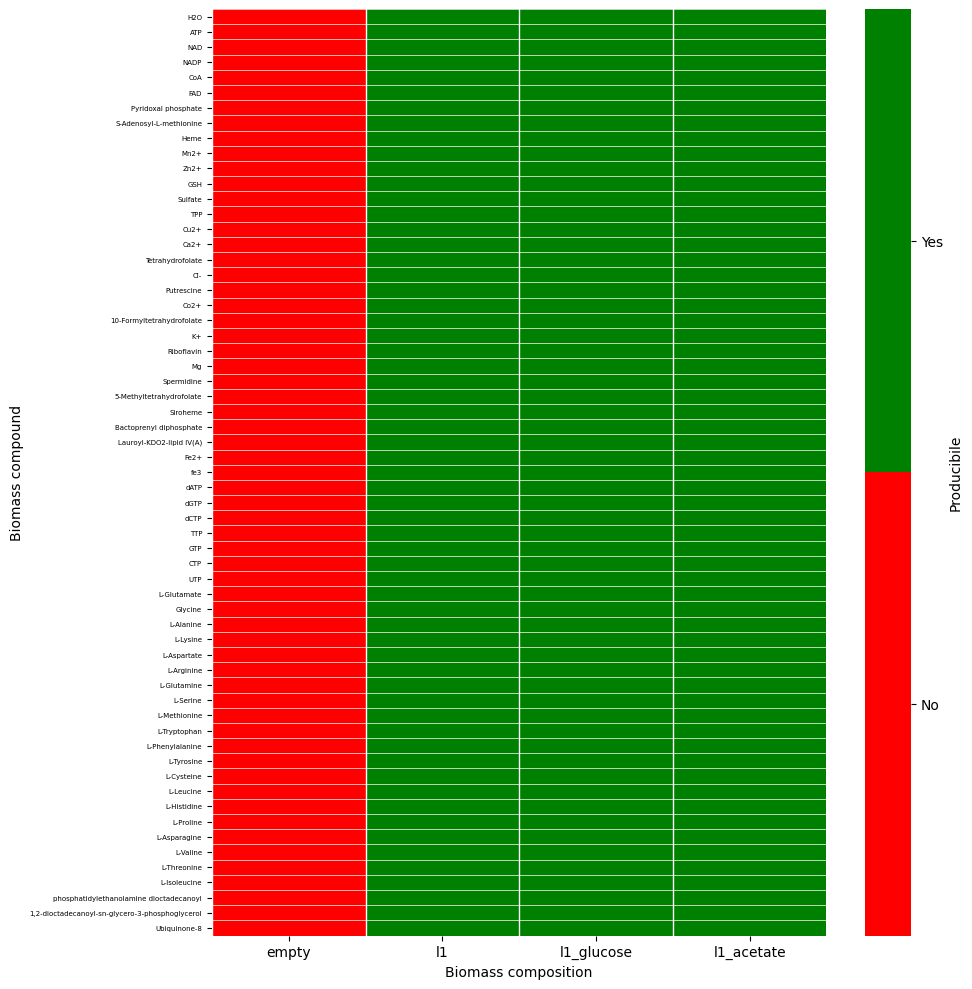

In [150]:
biomass.check_biomass_producibility(
    model,
    phenotypes_df,
    media_definitions
)

In [151]:
model

Name,iHS4156
Memory address,113222e90
Number of metabolites,1275
Number of reactions,2726
Number of genes,953
Number of groups,0
Objective expression,1.0*SK_cpd15560_c0 - 1.0*SK_cpd15560_c0_reverse_19a8d
Compartments,"c0, e0"


In [145]:
model.medium

{'EX_cpd00244_e0': 1000,
 'EX_cpd00029_e0': 1000,
 'EX_cpd00048_e0': 1000,
 'EX_cpd00254_e0': 1000,
 'EX_cpd00001_e0': 1000,
 'EX_cpd00063_e0': 1000,
 'EX_cpd00034_e0': 1000,
 'EX_cpd00099_e0': 1000,
 'EX_cpd00305_e0': 1000,
 'EX_cpd00205_e0': 1000,
 'EX_cpd10516_e0': 1000,
 'EX_cpd00058_e0': 1000,
 'EX_cpd00009_e0': 1000,
 'EX_cpd00007_e0': 20,
 'EX_cpd00030_e0': 1000,
 'EX_cpd00971_e0': 1000,
 'EX_cpd00149_e0': 1000,
 'EX_cpd00209_e0': 1000}

In [152]:
for metabolite in model.metabolites:
    # Check if there is already a sink reaction for this metabolite
    if "SK_" + metabolite.id not in [r.id for r in model.reactions]:
        model.add_boundary(metabolite, type="sink", lb=0)

In [154]:
solution = model.optimize()

In [155]:
solution

,fluxes,reduced_costs
rxn02201_c0,0.0,0.0
rxn00351_c0,0.0,0.0
rxn07431_c0,0.0,-0.0
rxn00836_c0,0.0,0.0
rxn00423_c0,0.0,0.0
...,...,...
SK_cpd00051_e0,0.0,0.0
SK_cpd00132_e0,0.0,-0.0
SK_cpd00085_e0,0.0,-0.0
SK_cpd00039_e0,0.0,-0.0


In [158]:
type(solution.fluxes)

pandas.core.series.Series

In [160]:
# Filter the pandas series to only show reactions with non-zero fluxes with IDs that start with "SK_"
sinks_used = solution.fluxes[[rxn_id for rxn_id in solution.fluxes.index if rxn_id.startswith("SK_") and abs(solution.fluxes[rxn_id]) > 1e-6]]

In [165]:
# Add a column to show the metabolite names
sinks_used_df = pd.DataFrame({
    "Reaction ID": sinks_used.index,
    "Metabolite Name": [
        list(model.reactions.get_by_id(rxn_id).metabolites.keys())[0].name
        for rxn_id in sinks_used.index
    ],
    "Flux": sinks_used.values,
})

In [169]:
sinks_used_df

,Reaction ID,Metabolite Name,Flux
0,SK_cpd00001_c0,H2O,972.295409
1,SK_cpd15560_c0,Ubiquinone-8,6.666667
2,SK_cpd00971_c0,Na+,1000.000000
3,SK_cpd00242_c0,H2CO3,594.118430
4,SK_cpd00058_c0,Cu2+,1000.000000
5,SK_cpd00063_c0,Ca2+,1000.000000
6,SK_cpd01080_c0,Octadecanoate,15.785096
7,SK_cpd15540_c0,"1,2-dioctadecanoyl-sn-glycero-3-phosphoglycerol",17.475050
8,SK_cpd00180_c0,Oxalate,30.565536
9,SK_cpd10515_c0,Fe2+,346.440452


In [168]:
sinks_used_df.to_markdown()

'|    | Reaction ID    | Metabolite Name                                 |       Flux |\n|---:|:---------------|:------------------------------------------------|-----------:|\n|  0 | SK_cpd00001_c0 | H2O                                             |  972.295   |\n|  1 | SK_cpd15560_c0 | Ubiquinone-8                                    |    6.66667 |\n|  2 | SK_cpd00971_c0 | Na+                                             | 1000       |\n|  3 | SK_cpd00242_c0 | H2CO3                                           |  594.118   |\n|  4 | SK_cpd00058_c0 | Cu2+                                            | 1000       |\n|  5 | SK_cpd00063_c0 | Ca2+                                            | 1000       |\n|  6 | SK_cpd01080_c0 | Octadecanoate                                   |   15.7851  |\n|  7 | SK_cpd15540_c0 | 1,2-dioctadecanoyl-sn-glycero-3-phosphoglycerol |   17.475   |\n|  8 | SK_cpd00180_c0 | Oxalate                                         |   30.5655  |\n|  9 | SK_cpd10515_c0 | Fe2+   

# Add an NAD+-dependent isocitrate dehydrogenase

In [76]:
# Try adding an NAD+-dependent isocitrate dehydrogenase
idc_reaction = cobra.Reaction("IDH_NAD")
idc_reaction.name = "NAD+-dependent isocitrate dehydrogenase"
idc_reaction.lower_bound = 0  # irreversible
idc_reaction.upper_bound = 1000 # arbitrary upper bound
idc_reaction.add_metabolites({
    model.metabolites.cpd00260_c0: -1,  # isocitrate
    model.metabolites.cpd00003_c0: -1,  # NAD+
    model.metabolites.cpd00024_c0: 1,   # alpha-ketoglutarate
    model.metabolites.cpd00011_c0: 1,   # CO2
    model.metabolites.cpd00004_c0: 1    # NADH
})


In [77]:
idc_reaction

Reaction identifier,IDH_NAD
Name,NAD+-dependent isocitrate dehydrogenase
Memory address,0x1130d1950
Stoichiometry,cpd00003_c0 + cpd00260_c0 --> cpd00004_c0 + cpd00011_c0 + cpd00024_c0 NAD + Isocitrate --> NADH + CO2 + 2-Oxoglutarate
GPR,
Lower bound,0
Upper bound,1000


In [78]:
model.add_reactions([idc_reaction])

In [79]:
model.reactions.IDH_NAD

Reaction identifier,IDH_NAD
Name,NAD+-dependent isocitrate dehydrogenase
Memory address,0x1130d1950
Stoichiometry,cpd00003_c0 + cpd00260_c0 --> cpd00004_c0 + cpd00011_c0 + cpd00024_c0 NAD + Isocitrate --> NADH + CO2 + 2-Oxoglutarate
GPR,
Lower bound,0
Upper bound,1000


In [80]:
# Check that the model grows
model.optimize()

,fluxes,reduced_costs
rxn02201_c0,0.0,-5.530710e-19
rxn00351_c0,0.0,-6.066708e-17
rxn07431_c0,0.0,-3.313753e-18
rxn00836_c0,0.0,-6.661578e-16
rxn00423_c0,0.0,-1.220172e-16
...,...,...
EX_cpd00085_e0,0.0,-2.223646e-01
EX_cpd00039_e0,0.0,1.637114e-16
EX_cpd00054_e0,0.0,-4.447293e-01
rxn15341_c0,0.0,9.751312e-17


In [81]:
# Set that as the objective
model.objective = "IDH_NAD"
model.optimize()

,fluxes,reduced_costs
rxn02201_c0,0.0,2.154600e-16
rxn00351_c0,0.0,-1.060301e-16
rxn07431_c0,0.0,5.148457e-17
rxn00836_c0,0.0,3.434258e-15
rxn00423_c0,0.0,2.267327e-14
...,...,...
EX_cpd00085_e0,0.0,-2.000000e+00
EX_cpd00039_e0,0.0,8.898945e-16
EX_cpd00054_e0,0.0,-4.000000e+00
rxn15341_c0,0.0,-1.857070e-17
